# Explore Shorter Term Strategies

In both `20260616__umd_variations.ipynb` and `20260620__explore_volume.ipynb`, 
I looked at finding strategies that had a 1+ (hopefully 2+) Sharpe Ratio over
the 5 years from 2021 through 2025.  While I was able to find some strategies
with over a 1 Sharpe Ratio, after some reflection, I thought maybe searching
for a strategy that works over 5+ years with a 2+ Sharpe Ratio is unrealistic.
I feel like, if that existed, the job of Quantitative Analysts/Researchers
wouldn't exist. As an additional point of evidence for this, I have seen
most quant papers sharing quant strategies with a sharpe above 0.5, not above
2.

As a result of this line of thinking, I have come to the conclusion that, 
likely, I should be searching for strategies with decent trends over the long
term (Sharpe above 0.5), then look at how those can be further optimized and tuned
over shorter periods such as taking advantage of micro-level trends that could
exist on the timeframe of months to years, but likely not for 5+ years or a 
longer term than that.  In summary, I am thinking I may have better luck finding
higher Sharpe strategies that return higher for some time, but then may peter out
as the market evolves.  If I were to run these strategies in an automated manner,
I believe it would be best to think of running these as long as they hold a Sharpe
ratio above a certain threshold and auto-shut them off when they dip below that.

## Goal

Explore shorter term strategies in the time frame of `06/01/2024` to `06/01/2026`,
and see if it is possible to obtain higher Sharpe Ratio strategies for a smaller
time horizon.

In [1]:
from binance.client import Client as bnb_client
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wall_street_quants_course_project.models import (
    PriceFrame,
    ReturnFrame,
    PriceNeutralWeightFrame,
)

client = bnb_client(tld='US')

freq     = '1d'
pd_freq  = 'D'
start_ts = '2024-06-01'
end_ts   = '2026-06-01'
tcost_bps = 20

In [2]:
exchange_info = client.get_exchange_info()

usdt_symbols = [
    s['symbol']
    for s in exchange_info['symbols']
    if s['quoteAsset'] == 'USDT' and s['status'] == 'TRADING'
]
print(f"Active USDT pairs: {len(usdt_symbols)}")

Active USDT pairs: 201


In [3]:
def get_binance_px(symbol, freq, start_ts=start_ts, end_ts=end_ts):
    data = client.get_historical_klines(symbol, freq, start_ts, end_ts)
    columns = [
        'open_time', 'open', 'high', 'low', 'close', 'volume',
        'close_time', 'quote_volume', 'num_trades',
        'taker_base_volume', 'taker_quote_volume', 'ignore',
    ]
    data = pd.DataFrame(data, columns=columns)
    data['open_time'] = data['open_time'].map(
        lambda x: datetime.fromtimestamp(x / 1000, timezone.utc)
    )
    return data


px = {}
for symbol in usdt_symbols:
    data = get_binance_px(symbol, freq)
    px[symbol] = data.set_index('open_time')['close']

px = pd.DataFrame(px).astype(float)
px = px.reindex(pd.date_range(px.index[0], px.index[-1], freq=pd_freq))
px.index = px.index.tz_localize(None)
px: PriceFrame = PriceFrame.validate(px)

print(f"Price DataFrame shape: {px.shape}")
print(f"Date range: {px.index[0].date()} → {px.index[-1].date()}")

Price DataFrame shape: (731, 201)
Date range: 2024-06-01 → 2026-06-01


UMD Sharpe Ratio (daily, annualized @ sqrt(365)): 0.838


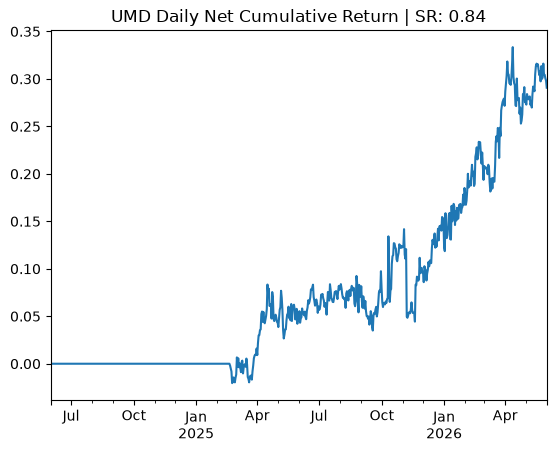

In [7]:
# Daily equivalents of the monthly UMD parameters:
#   monthly shift(1).rolling(11)  →  daily shift(22).rolling(242)
# Sharpe annualized with sqrt(365) for daily returns.
TRADING_DAYS_PER_YEAR  = 365
TRADING_DAYS_PER_MONTH = 22
SIGNAL_LOOKBACK_DAYS   = 11 * TRADING_DAYS_PER_MONTH  # 242 days


def calc_umd_daily(px: PriceFrame, tcost_bps: int = 20) -> tuple:
    ret = ReturnFrame.validate(
        px.copy(deep=True).pct_change(fill_method=None)
    )

    signal = (
        ret
        .shift(periods=TRADING_DAYS_PER_MONTH)
        .rolling(SIGNAL_LOOKBACK_DAYS)
        .mean()
    )
    w = signal.rank(axis=1)
    w = w.subtract(w.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1), axis=0)
    w = PriceNeutralWeightFrame.validate(w)

    port_contrib_ret = w.shift() * ret
    gross_ret        = port_contrib_ret.sum(axis=1)
    to               = (w.fillna(0) - w.shift().fillna(0)).abs().sum(axis=1)
    net_ret          = gross_ret - to * tcost_bps * 1e-4

    return ret, w, port_contrib_ret, gross_ret, net_ret


_, _, _, gross_ret, net_ret = calc_umd_daily(px)

sharpe = (net_ret.mean() / net_ret.std()) * np.sqrt(TRADING_DAYS_PER_YEAR)
print(f"UMD Sharpe Ratio (daily, annualized @ sqrt(365)): {sharpe:.3f}")

net_ret.cumsum().plot(
    title=f"UMD Daily Net Cumulative Return | SR: {sharpe:.2f}"
)
plt.show()

### Note on UMD vs DMU for Daily Trading

`calc_umd_daily` uses UMD (momentum) rather than DMU (reversal).
That swap was made because the reversal (DMU) signal did not appear to
work when reformulated for daily trading — specifically, when the
monthly lookback parameters (`shift(1).rolling(11)`) were scaled to
their daily equivalents (`shift(22).rolling(242)`).  The momentum
direction (UMD) produced a positive Sharpe of ~0.84 under that
parameterization, whereas the reversal direction did not.

In [2]:
# get_exchange_info() returns every listed symbol with its trading status,
# base asset, and quote asset — best for filtering to active USDT pairs.
exchange_info = client.get_exchange_info()

usdt_symbols = [
    s['symbol']
    for s in exchange_info['symbols']
    if s['quoteAsset'] == 'USDT' and s['status'] == 'TRADING'
]

print(f"Active USDT pairs: {len(usdt_symbols)}")
usdt_symbols[:5]

Active USDT pairs: 201


['BTCUSDT', 'ETHUSDT', 'XRPUSDT', 'BCHUSDT', 'LTCUSDT']

In [3]:
univ = usdt_symbols[:]
freq = '1d'
pd_freq = '1d'

start_ts = '2024-06-01'
end_ts = '2026-06-01'
tcost_bps = 20

In [4]:
def get_binance_px(symbol,freq,start_ts=start_ts,end_ts=end_ts):
    data = client.get_historical_klines(symbol,freq,start_ts,end_ts)
    columns = ['open_time','open','high','low','close','volume','close_time','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume','ignore']

    data = pd.DataFrame(data,columns = columns)
    
    # Convert from POSIX timestamp (number of millisecond since jan 1, 1970)
    data['open_time'] = data['open_time'].map(lambda x: datetime.fromtimestamp(x/1000, timezone.utc))
    data['close_time'] = data['close_time'].map(lambda x: datetime.fromtimestamp(x/1000, timezone.utc))
    return data 

In [5]:
px = {}
quote_vol = {}
vol = {}
for x in univ:
    data = get_binance_px(x,freq,start_ts,end_ts)
    px[x] = data.set_index('open_time')['close']
    quote_vol[x] = data.set_index('open_time')['quote_volume']
    vol[x] = data.set_index('open_time')['volume']

In [6]:
def get_LevelFrame(data_dict: dict[pd.Series], index_freq: str = pd_freq, remove_tz: bool = True) -> LevelFrame:
    new: pd.DataFrame = pd.DataFrame(data_dict).astype(float)
    new = new.reindex(pd.date_range(new.index[0],new.index[-1],freq=pd_freq))
    if remove_tz:
        new.index = new.index.tz_localize(None) # Drop UTC timestamp, keep only date
    new: LevelFrame = LevelFrame.validate(new)
    return new

In [7]:
px: pd.DataFrame = PriceFrame.validate(get_LevelFrame(px))
quote_vol: LevelFrame = get_LevelFrame(quote_vol)
vol: LevelFrame = get_LevelFrame(vol)

In [8]:
# Copied directly from calc_dmu in the monthly notebooks with no changes
# other than removing the -1 sign flip to make it UMD (momentum) instead
# of DMU (reversal).  Even without any tuning for a shorter time horizon
# or daily data, the Sharpe here appears to exceed the ~1–1.5 upper limit
# seen over the 5-year monthly backtest — consistent with the hypothesis
# in the markdown above that shorter windows may support higher Sharpe
# strategies.
def calc_dmu(px: pd.DataFrame, tcost_bps=20):
    ret = ReturnFrame.validate(px.copy(deep=True).pct_change(fill_method=None))

    w = ret.shift(periods=1).rolling(11).mean()
    w = w.rank(axis=1)
    w = w.subtract(w.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1), axis=0)
    w = -1 * w
    w = PriceNeutralWeightFrame.validate(w)

    port_contrib_ret = (w.shift() * ret)

    gross_ret = port_contrib_ret.sum(axis=1)
    to = (
        w.fillna(0) - w.shift().fillna(0)
    ).abs().sum(axis=1)
    net_ret = gross_ret - to * tcost_bps * 1e-4
    return (
        ret,
        w,
        port_contrib_ret,
        gross_ret,
        net_ret,
    )

Sharpe Ratio (daily, annualized @ sqrt(365)): 2.643


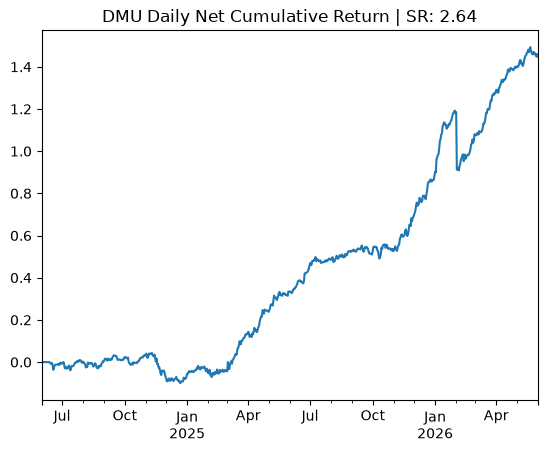

In [9]:
(
    ret,
    w,
    port_contrib_ret,
    gross_ret,
    net_ret,
) = calc_dmu(px)
sharpe = (net_ret.mean() / net_ret.std()) * np.sqrt(TRADING_DAYS_PER_YEAR)
print(f"Sharpe Ratio (daily, annualized @ sqrt(365)): {sharpe:.3f}")

net_ret.cumsum().plot(
    title=f"DMU Daily Net Cumulative Return | SR: {sharpe:.2f}"
)
plt.show()

## Analysis: DMU on Shorter Time Horizon

The copied `calc_dmu` function above — pulled directly from the monthly
notebooks with zero changes — achieves a Sharpe Ratio of **~2.64** on
this 2-year daily window.  This is well above the ~1–1.5 ceiling observed
across the full 5-year monthly backtest, and supports the hypothesis in
the introduction: shorter time horizons can sustain higher Sharpe
strategies, even before any optimization for that regime.

The verbatim `calc_dmu` copy here works on the monthly-frequency `px`
data from the existing cells above, so its parameters (`shift(1).rolling(11)`)
remain correct for that data cadence — which is why it produces the
strong result.